In [60]:
from utils import * 
import subprocess
import json
from Bio.Align import PairwiseAligner 
import itertools
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from orf import * 

%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
msa_dir_path = '../data/genes/mmseqs/'

def get_msas_unpaired(gene_ids:list, dir_path:str='../data/genes/mmseqs/'):
    '''Load the unpaired MSAs for the specified gene IDs.
    
    :param gene_ids: The IDs of the genes to construct paired MSAs for. These should all be from the same genome.   
    :param dir_path: The path to the directory where the MSAs are stored. This function assumes the a3m files have names matching the gene ID of the query 
        sequence. 
    '''
    paths = {gene_id:os.path.join(dir_path, f'{gene_id}.a3m') for gene_id in gene_ids}
    return {gene_id:str(FASTAFile.from_file(path)) for gene_id, path in paths.items()}


# Cluster analysis: **cluster_20**

The cluster_20 proteins compose a group of small membrane-associate alpha-helical proteins. Analysis of the metatranscriptomic data indicates that the cluster_20 protein on bz_0 is expressed in large quantities concomitantly with cluster_25 in 2025 samples. Therefore, if Betazoids do engage in a viral-like life cycle, it is likely that these proteins play an important role. 

In [1]:
cluster_id = 20

In [4]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[(genes_df.cluster_id == cluster_id)].copy()

# Write the protein sequences to a FASTA file and create an MSA. 
msa_path = f'../data/genes/cluster_{cluster_id}.afa'
FASTAFile.from_df(genes_df).write(f'../data/genes/cluster_{cluster_id}.faa')
if not os.path.exists(msa_path):
    subprocess.run(f'muscle -align ../data/genes/cluster_{cluster_id}.faa -output {msa_path}', shell=True, check=True)
msa = MSAFile.from_file(msa_path)

print('Number of genes:', len(genes_df))
print('Maximum length:', genes_df.seq.apply(len).max())
print('Minimum length:', genes_df.seq.apply(len).min())

print()
print(str(FASTAFile.from_df(genes_df)))

Number of genes: 3
Maximum length: 97
Minimum length: 96

>orfm.bz_0.1_114
MSNKNKAMVMLLIVAGVFALSASAVSATSCTDAGDFVGICNTVIGIANGTLAVISILFTGNNASIIIEAALIVTIVGAILDLSRGKSSWLRSKFERV
>orfm.bz_4.1_121
MVNRKYLTVFLIAVGMIVLTASNVGATACSDAGDFEGVCTSLSGLFNATMALISIVATGSNASIIITAAVILAIVTFFVDMARGEKSWLRAKMRNL
>orfm.bz_11.1_116
MITSKKILFSTIMIVSIAFLTLPATATVCSDAGSFNSTCVTITDLGKGIIAVFSVLVTGDNAGVLITTAITIAIVVAVFDLSRGKESYIGRHFRRM



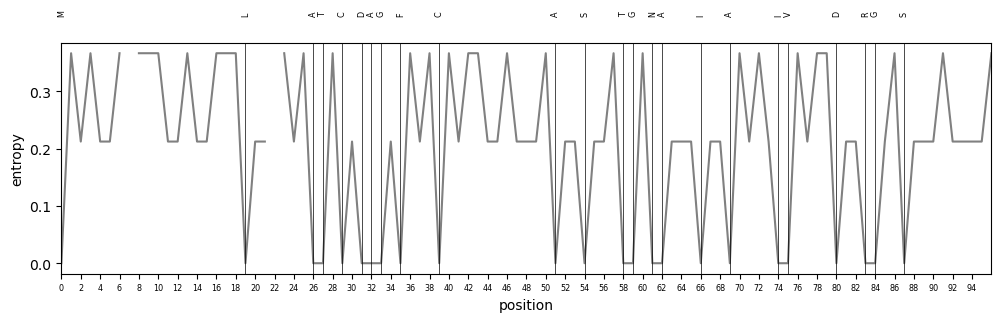

In [44]:
fig, ax = plt.subplots(figsize=(12, 3))
plot_entropy(msa, ax=ax, annotate=True, x_min=0, x_max=96)
plt.show()

In [9]:
annot_df = pd.read_csv('../data/genes/interproscan/genes.tsv', sep='\t', header=None, names=INTERPROSCAN_FIELDS)
tmhmm_df = TMHMMFile.from_file('../data/genes/tmhmm/genes.txt').to_df()

for gene_id in genes_df.index:
    n_annotations = len(annot_df[annot_df.gene_id == gene_id])
    n_tmhs = len(tmhmm_df[(tmhmm_df.gene_id == gene_id) & (tmhmm_df.annotation == 'TMhelix')])
    print(f'{gene_id}    Number of annotations: {n_annotations}   Number of TMHs: {n_tmhs}')

orfm.bz_0.1_114    Number of annotations: 1   Number of TMHs: 3
orfm.bz_4.1_121    Number of annotations: 1   Number of TMHs: 2
orfm.bz_11.1_116    Number of annotations: 0   Number of TMHs: 2


Two of the cluster_20 proteins have weak InterProScan annotations for a [prokaryotic lipoprotein lipid attachment site](https://www.ebi.ac.uk/interpro/entry/profile/PS51257/). These are a type of signal peptide, which are cleaved upstream of a cysteine residue to which a glyceride-fatty acid lipid is attached. Although these do exist in archaea [[Storf et. al. 2010](https://pmc.ncbi.nlm.nih.gov/articles/PMC2945643)], the hits are extremely weak (E-value of 6). 

Due to this prediction and the inconsistent TMHMM predictions, we additionally ran both DeepTMHMM and SignalP (version 6.0) on the cluster_20 proteins. 


In [108]:
for gene_id in genes_df.index:
    deep_tmhmm_df = DeepTMHMMFile.from_file(f'../data/genes/deep_tmhmm/{gene_id}.gff3').to_df()

    SIGNALP_FIELDS = ['gene_id', 'prediction', 'other', 'sp_sec_spi', 'lipo_sec_spii', 'tat_tat_spi', 'tatlipo_tat_spii', 'pilin_sec_spiii', 'cleavage_site_position']
    signalp_df = pd.read_csv(f'../data/genes/signalp/{gene_id}.txt', sep='\t', comment='#', names=SIGNALP_FIELDS)

    print(f'{gene_id}    Topology type: {deep_tmhmm_df.topology_string.iloc[0]}')


orfm.bz_0.1_114    Topology type: SOMI
orfm.bz_4.1_121    Topology type: SOMI
orfm.bz_11.1_116    Topology type: SOMI


Based on their high expression level, it seems likely that these proteins are central to the Betazoid life cycle. Therefore, it is unusual that homologs are only identified in 3 of the 11 Betazoid genomes. Due to their small size and simple structure, it is possible that other proteins in the cluster_20 family are too divergent at the sequence level to be captured by a sequence-based similarity search. We therefore conducted a more thorough search of the other Betazoid genomes. We performed a preliminary scan of all Betazoid genomes using the following criteria: 

1. **Shorter than 110 residues in length.** We opted against placing a lower bound on size, as (1) the MCPs filamentous bacteriophage MCPs are ~50 aa following signal peptide cleavage, and (2) it is unclear if a signal peptide is required. 

2. **At least one transmembrane helix.** 

3. **At least 2 positive residues (K or R) in the last 10 amino acids.** This is based on the observation that all identified cluster_20 proteins appear to have a positive C-terminus. This is characteristic of filamentous phage MCPs (wherein these postive residues are predicted to interact with the phage DNA), as well as more generally in transmembrane proteins (the "positive inside" rule). 

4. **Supported by Prodigal predictions.** It seems as though essentially all of the annotated genes are predicted by Prodigal, and wading through all OrfM candidates is somewhat intractable.

*These criteria are partially informed by inspection of the proteins obtained by the BLAST search against ggKbase, which is described in the following section.*

In [109]:
candidate_genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
candidate_genes_df['cluster_id'] = candidate_genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
# candidate_genes_df['genome_id'] = [get_genome_id(gene_id) for gene_id in candidate_genes_df.index]
candidate_genes_df['num_tmhs'] = tmhmm_df[tmhmm_df.annotation == 'TMhelix'].groupby('gene_id').size()

filters = dict()
filters['longer_than_110_aa'] = (candidate_genes_df.length_from_start_codon > 110)
filters['no_transmembrane_helix'] = candidate_genes_df.num_tmhs.isnull() # Probably should expect two (one being a signal peptide).
filters['in_the_bz_12_genome'] = candidate_genes_df.genome_id == 'bz_12' # This is probably not a Betazoid.
filters['not_supported_by_prodigal'] = candidate_genes_df.prodigal_gene_id.isnull()
filters['no_positive_c_terminal_residues'] = (candidate_genes_df.seq.str[-10:].str.count('K') + candidate_genes_df.seq.str[-10:].str.count('R')) < 2

candidate_genes_df = apply_filters(filters, candidate_genes_df)
candidate_gene_ids = candidate_genes_df.index.values

print('\nNumber of genomes with cluster_20 homolog candidates:', candidate_genes_df.genome_id.nunique())
print('Number of candidate genes:', len(candidate_gene_ids))

FASTAFile.from_df(candidate_genes_df).write('0-cluster-analysis-cluster_20-candidate_genes.faa')


apply_filters: 176 entries removed by longer_than_110_aa.
apply_filters: 1100 entries removed by no_transmembrane_helix.
apply_filters: 105 entries removed by in_the_bz_12_genome.
apply_filters: 1204 entries removed by not_supported_by_prodigal.
apply_filters: 1041 entries removed by no_positive_c_terminal_residues.

Number of genomes with cluster_20 homolog candidates: 11
Number of candidate genes: 37


## BLAST search

Because the predicted structures are so weak, and because the topology predictions are somewhat inconsistent (at least the output of TMHMM), we sought to identify other potential homologs in ggKbase. After BLASTing the amino acid sequences against all datasets, we downloaded the nucleotide and protein sequences of all hits. We subsequently removed duplicate sequences, as well as sequences exceeding 110 residues in length. 

This search process yielded only two novel cluster_20 genes: **Dalian_Groundwater_SRR22387926_scaffold_135972_3** and **SR-VP_9_9_2021_59_4A_0_85m_scaffold_34976_2**. The other hits are either identical to an existing cluster_20 gene, or differ only by the selected start site. 


In [12]:
blast_ggkbase_dir = '../data/genes/blast/ggkbase/'

In [ ]:
blast_ggkbase_df = list()
for gene_id in genes_df.index:
    fna_path, faa_path = os.path.join(blast_ggkbase_dir, f'{gene_id}.fna'), os.path.join(blast_ggkbase_dir, f'{gene_id}.faa')
    df = FASTAFile.from_file(fna_path).to_df().rename(columns={'seq':'nt_seq'}).drop(columns='description')
    df = pd.concat([df, FASTAFile.from_file(faa_path).to_df()], axis=1)
    blast_ggkbase_df += [df]

blast_ggkbase_df = pd.concat(blast_ggkbase_df)
blast_ggkbase_df.index = [gene_id.split('|')[0] for gene_id in blast_ggkbase_df.index] # Clean up the ggKbase gene IDs.
blast_ggkbase_df['seq'] = blast_ggkbase_df.seq.str.replace('*', '', regex=False)
blast_ggkbase_df['contig_id'] = ['_'.join(gene_id.split('_')[:-1]) for gene_id in blast_ggkbase_df.index]
blast_ggkbase_df['project_id'] = [gene_id.split('_scaffold_')[0] for gene_id in blast_ggkbase_df.index]
# Parse the descriptions from the FASTA files to get the gene start and stop positions. 
blast_ggkbase_df['start'] = blast_ggkbase_df.description.apply(lambda description : int(description.split('#')[1].strip())) # Convert to zero-indexed for my sanity. 
blast_ggkbase_df['stop'] = blast_ggkbase_df.description.apply(lambda description : int(description.split('#')[2].strip()))
blast_ggkbase_df['strand'] = blast_ggkbase_df.description.apply(lambda description : int(description.split('#')[3].strip())).replace({-1:'-', 1:'+'})

filters = dict()
filters['duplicated_nt_seq'] = blast_ggkbase_df.duplicated('nt_seq')
filters['longer_than_110_aa'] = blast_ggkbase_df.seq.apply(len) > 110
blast_ggkbase_df = apply_filters(filters, blast_ggkbase_df)


print('\nNumber of cluster_20 genes represented in the BLAST dataset (OrfM):', genes_df.seq.isin(blast_ggkbase_df.seq.values).sum())
print('Number of cluster_20 genes represented in the BLAST dataset (Prodigal):', genes_df.prodigal_seq.isin(blast_ggkbase_df.seq.values).sum())

apply_filters: 122 entries removed by duplicated_nt_seq.
apply_filters: 19 entries removed by longer_than_100_aa.

Number of cluster_20 genes represented in the BLAST dataset (OrfM): 2
Number of cluster_20 genes represented in the BLAST dataset (Prodigal): 3


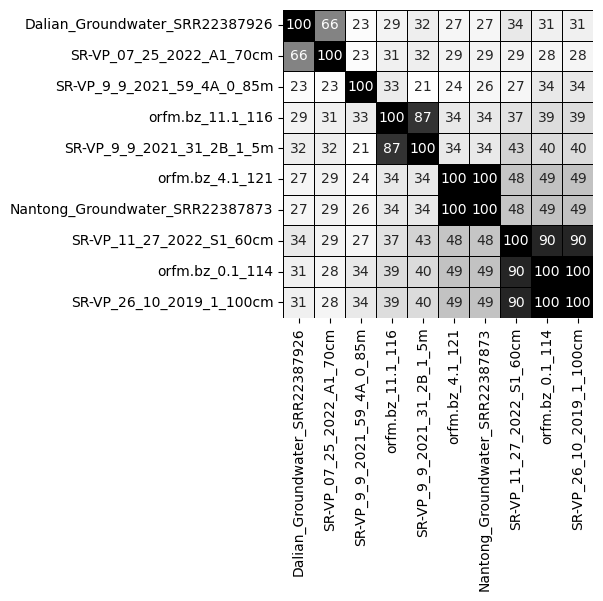

In [51]:

figure_df = get_pairwise_alignments(pd.concat([genes_df, blast_ggkbase_df.set_index('project_id')]).seq, metric='identities', normalize=True)
figure_df[figure_df == 0] = 1 # Fill the diagonals with 1 to make a true similarity matrix. 

z = linkage(squareform(1 - figure_df.values))
order = leaves_list(z)
figure_df = figure_df.iloc[order, order].copy()

min_alignment_length = 60
alignment_lengths =  get_pairwise_alignments(genes_df.seq, metric='aligned', normalize=False).values
alignment_lengths = alignment_lengths[np.triu_indices(len(alignment_lengths), k=1)].ravel()
assert alignment_lengths.min() > min_alignment_length, f'Some of the pairwise alignments failed, minimum alignment length is {alignment_lengths.min()}.'

fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap((figure_df * 100).astype(int), cmap='Grays', annot=True, cbar=False, linewidth=0.5, linecolor='black', fmt='d')
ax.set_ylabel('')
ax.set_xlabel('')
plt.show()

In [49]:
# Write the protein sequences to a FASTA file and create an MSA. 
msa_path = f'0-cluster-analysis-cluster_{cluster_id}-blast_ggkbase.afa'
path = f'0-cluster-analysis-cluster_{cluster_id}-blast_ggkbase.faa'
FASTAFile.from_df(blast_ggkbase_df).write(path)
if not os.path.exists(msa_path):
    subprocess.run(f'muscle -align {path} -output {msa_path}', shell=True, check=True)
msa = MSAFile.from_file(msa_path)

msa.show()

0	MHVMRNMSGCLKAIRNKLAVTSIIMAGAI....SGASATVSTADLGTWASLANLTTQLFLTGLYVVQEILTGDNASTLIYGIIVFAIVMAVLDLRKP.........DSI	109	SR-VP_9_9_2021_59_4A_0_85m_scaffold_34976_2
0	MVN...........R.KYLTVFLIAVGMIVLTASNVGAT.ACSDAGDFEGVCTSLSGLFNATMALISIVATGSNASIIITAAVILAIVTFFVDMARGEKSWLRAKMRNL	109	Nantong_Groundwater_SRR22387873_scaffold_1350_25
0	MSN...........KNKAMVMLLIVAGVFALSASAVSAT.SCTDAGDFVGICNTVIGIANGTLAVISILFTGNNASIIIEAALIVTIVGAILDLSRGKSSWLRSKFERV	109	SR-VP_26_10_2019_1_100cm_scaffold_2098_23
0	M....................LLIVAGVFALSASAVSAT.SCTDAGDFVGICNTVIGIANGTLAVISILFTGNNASIIIEAALIVTIVGAILDLSRGKSSWLRSKFERV	109	SR-VP_11_27_2022_S1_60cm_scaffold_16350_2
0	M....................I.VSIAFLTL...PATAT.VCSDAGSFNSTCVTITDLGKGIIAVFSVLVTGDNAGVLITTAITIAIVVAVFDLSRGKESYIGRHFRRM	109	SR-VP_9_9_2021_31_2B_1_5m_scaffold_23596_3
0	...........................................MSGQFDSLATLVTDLANATLTVASTIFTGNNAGIVLSAIVVIVLVVLFLRIPDK....LYDYLKMR	109	Dalian_Groundwater_SRR22387926_scaffold_135972_3
0	.................................

Inspection of the MSA for the ggKbase hits reveals that the N-terminal helix appears to be dispensible. We also considered the possibility that the missing N-terminus is a result of erroneous ORF calling (either N-terminal extension or truncation); this appears to be the case for orfm.bz_11.1_116, which has an alternate start site about 30 bp upstream of the Prodigal-selected start site. To evaluate the possibility of alternate start sites for all sequences, we did the following:

1. Downloaded the full-length contig encoding each gene. 

2. Extended each sequence at the N-terminus by up to 30 residues in each possible frame. We tried multiple frames to account for the possibility of assembly error. 

3. Identified potential start codons downstream of the selected start. 

Based on the results, all but two genes have an ORF configuration which is around 95 amino acids in length. Furthermore, none of the genes with an N-terminus hav an alternate in-frame start codon which would fully remove the N-terminal 30 residues. This, in combination with the strong SignalP predictions and fact that the hydrophobicity of the N termini is consistent, suggests that the N-terminal region is valid. 

However, the two shorter genes (SR-VP_07_25_2022_A1_70cm_scaffold_29863_3 and Dalian_Groundwater_SRR22387926_scaffold_135972_3) do not have a valid N-terminal extension. This implies that the N-terminal hydrophobic helix is dispensible, and otherwise not essential for protein function. This supports the SignalP predictions; if the N terminus is indeed a signal peptide, it would be cleaved upon membrane localization. 

In [91]:
contigs = {os.path.basename(path).replace('.fasta', ''):FASTAFile.from_file(path).seqs[0] for path in glob.glob('../data/genes/contigs/*')}
blast_ggkbase_df['contig'] = blast_ggkbase_df.contig_id.map(contigs)

df = list()
for row in blast_ggkbase_df.itertuples():
    df += [orf_get_alternate(row.start, row.stop, row.strand, contig=row.contig, frame_shift=0).assign(gene_id=row.Index)]
    df += [orf_get_alternate(row.start, row.stop, row.strand, contig=row.contig, frame_shift=1).assign(gene_id=row.Index)]
    df += [orf_get_alternate(row.start, row.stop, row.strand, contig=row.contig, frame_shift=2).assign(gene_id=row.Index)]
df = pd.concat(df)

filters = dict()
filters['in_frame_stop_codon'] = df.seq.str.count(r'\*') > 1
filters['uncommon_start_codon'] = df.start_codon == 'TTG'
filters['shorter_than_50_aa'] = df.length < 50
filters['longer_than_110_aa'] = df.length > 110
filters['duplicated_seq'] = df.seq.duplicated(keep='first') & df.gene_id.duplicated(keep='first')
filters['requires_frame_shift'] = df.frame_shift != 0

apply_filters(filters, df)


apply_filters: 15 entries removed by in_frame_stop_codon.
apply_filters: 39 entries removed by uncommon_start_codon.
apply_filters: 21 entries removed by shorter_than_50_aa.
apply_filters: 6 entries removed by longer_than_110_aa.
apply_filters: 61 entries removed by duplicated_seq.
apply_filters: 73 entries removed by requires_frame_shift.


,start_codon,start_codon_idx,nt_seq,seq,frame_shift,original_length,length,gene_id
1,ATG,30,ATGAGCAATAAAAATAAAGCAATGGTAATGCTTCTGATAGTTGCTG...,MSNKNKAMVMLLIVAGVFALSASAVSATSCTDAGDFVGICNTVIGI...,0,98,98,SR-VP_26_10_2019_1_100cm_scaffold_2098_23
2,ATG,37,ATGGTAATGCTTCTGATAGTTGCTGGCGTATTTGCTTTGAGTGCTT...,MVMLLIVAGVFALSASAVSATSCTDAGDFVGICNTVIGIANGTLAV...,0,98,91,SR-VP_26_10_2019_1_100cm_scaffold_2098_23
3,ATG,39,ATGCTTCTGATAGTTGCTGGCGTATTTGCTTTGAGTGCTTCGGCTG...,MLLIVAGVFALSASAVSATSCTDAGDFVGICNTVIGIANGTLAVIS...,0,98,89,SR-VP_26_10_2019_1_100cm_scaffold_2098_23
1,ATG,18,ATGATAACCAGCAAAAAAATATTATTCTCAACAATAATGATAGTAA...,MITSKKILFSTIMIVSIAFLTLPATATVCSDAGSFNSTCVTITDLG...,0,85,97,SR-VP_9_9_2021_31_2B_1_5m_scaffold_23596_3
2,ATG,30,ATGATAGTAAGTATAGCTTTTTTGACTCTTCCAGCTACCGCAACTG...,MIVSIAFLTLPATATVCSDAGSFNSTCVTITDLGKGIIAVFSVLVT...,0,85,85,SR-VP_9_9_2021_31_2B_1_5m_scaffold_23596_3
0,ATG,30,ATGCATGTAATGAGAAATATGTCAGGATGCCTTAAAGCTATAAGAA...,MHVMRNMSGCLKAIRNKLAVTSIIMAGAISGASATVSTADLGTWAS...,0,97,97,SR-VP_9_9_2021_59_4A_0_85m_scaffold_34976_2
1,ATG,33,ATGAGAAATATGTCAGGATGCCTTAAAGCTATAAGAAATAAATTAG...,MRNMSGCLKAIRNKLAVTSIIMAGAISGASATVSTADLGTWASLAN...,0,97,94,SR-VP_9_9_2021_59_4A_0_85m_scaffold_34976_2
2,ATG,36,ATGTCAGGATGCCTTAAAGCTATAAGAAATAAATTAGCTGTTACAT...,MSGCLKAIRNKLAVTSIIMAGAISGASATVSTADLGTWASLANLTT...,0,97,91,SR-VP_9_9_2021_59_4A_0_85m_scaffold_34976_2
3,ATG,54,ATGGCTGGTGCAATATCCGGTGCATCGGCTACCGTTTCAACGGCTG...,MAGAISGASATVSTADLGTWASLANLTTQLFLTGLYVVQEILTGDN...,0,97,73,SR-VP_9_9_2021_59_4A_0_85m_scaffold_34976_2
1,ATG,30,ATGAGCGGACAATTTGATTCACTGGCCACATTGGTAACAGATTTAG...,MSGQFDSLATLVTDLANATLTVASTIFTGNNAGIVLSAIVVIVLVV...,0,63,63,Dalian_Groundwater_SRR22387926_scaffold_135972_3


## Physicochemical analysis

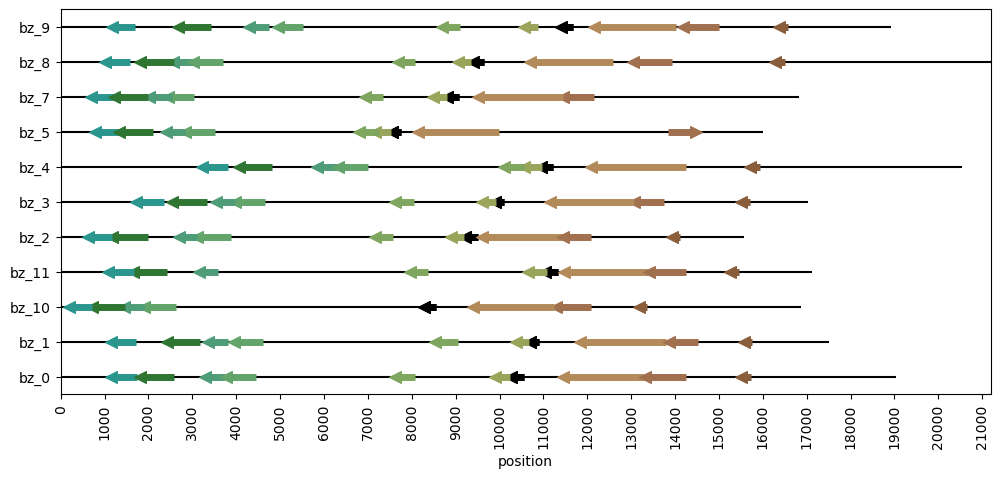

In [ ]:
cluster_ids = df.cluster_id.values.tolist() + [8, 7, 0, 4, 5, 6, 1, 3, 2]

colors = ['#8A5E3B', '#A0704F', '#B38A5A', '#9AA45A', '#7FA65E', '#62A46A', '#4F9D78', "#2F7632", "#2B968E", "#5691D8", "#323986"]

palette = dict(zip([8, 7, 0, 4, 5, 6, 1, 3, 2], colors))

fig, ax = plt.subplots(figsize=(12, 5))

figure_df = df.copy()
figure_df = pd.concat([figure_df, pd.read_csv('../data/genes/genes.csv', index_col=0)])
figure_df['cluster_id'] = figure_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
figure_df['gene_id'] = figure_df.index
figure_df = figure_df[figure_df.cluster_id.isin(cluster_ids)].copy()

plot_orfs(figure_df, ax=ax, palette=palette)



In [180]:
# Use the DeepTMHMM signal peptide predictions, to process the genes, i.e. remove the signal peptide. 
# This is just removing the amino acids classified as part of a signal protein from the alignment. 

topology_strings = deep_tmhmm_df.topology_string_full.to_dict()

for row in df.itertuples():
    topology = np.array(list(topology_strings[row.Index].strip())) 
    seq = np.array(list(row.seq))
    seq_processed = ''.join(seq[topology != 'S'])

    if row.Index == 'orfm.bz_5.1_98': # Length doesn't make as much sense with this one. 
        seq_processed = row.seq

    df.loc[row.Index, 'seq_processed'] = seq_processed # Add the sequence with the signal peptide removed to the DataFrame. 
    print(f'Signal peptide length in {row.Index}:', (topology == 'S').sum(), f'({len(seq_processed)} aa)', '(supported by SignalP)' if (row.num_sp_predictions > 1) else '')

Signal peptide length in orfm.bz_0.1_114: 27 (70 aa) (supported by SignalP)
Signal peptide length in orfm.bz_1.1_76: 0 (67 aa) 
Signal peptide length in orfm.bz_2.1_95: 24 (72 aa) 
Signal peptide length in orfm.bz_3.1_97: 0 (63 aa) 
Signal peptide length in orfm.bz_4.1_121: 26 (70 aa) (supported by SignalP)
Signal peptide length in orfm.bz_5.1_98: 20 (67 aa) 
Signal peptide length in orfm.bz_7.1_99: 0 (68 aa) 
Signal peptide length in orfm.bz_8.1_147: 21 (64 aa) (supported by SignalP)
Signal peptide length in orfm.bz_9.1_116: 0 (57 aa) 
Signal peptide length in orfm.bz_10.1_77: 28 (61 aa) 
Signal peptide length in orfm.bz_11.1_116: 26 (70 aa) (supported by SignalP)


In [182]:
genes_df = df.copy()
genes_df['gc_content'] = genes_df.nt_seq.apply(get_gc_content)

for row in genes_df.itertuples():
    print(f'{row.Index} ({row.start}-{row.stop}) {row.gc_content * 100:.1f}% GC')


orfm.bz_0.1_114 (10257-10553) 37.8% GC
orfm.bz_1.1_76 (10692-10898) 33.8% GC
orfm.bz_2.1_95 (9218-9521) 34.4% GC
orfm.bz_3.1_97 (9897-10095) 34.4% GC
orfm.bz_4.1_121 (10937-11230) 37.5% GC
orfm.bz_5.1_98 (7554-7766) 33.3% GC
orfm.bz_7.1_99 (8801-9076) 35.8% GC
orfm.bz_8.1_147 (9386-9652) 33.7% GC
orfm.bz_9.1_116 (11395-11677) 37.4% GC
orfm.bz_10.1_77 (8287-8563) 34.1% GC
orfm.bz_11.1_116 (11033-11324) 37.8% GC


In [186]:
# Write the processed sequences to a FASTA file for alignment. 

database_df = genes_df.copy()
database_path = '../data/genes/cluster_20.faa'
name = 'cluster_20_processed'

FASTAFile.from_df(database_df.assign(seq=database_df.seq_processed, description='')).write(database_path)
msa_main(database_path, query_gene_ids=df.index.tolist(), fmt='afa', name=name, output_dir='../data/genes/muscle', min_coverage=0.9)

# Also generate MSAs in the correct format for AlphaFold.
msa_paths = msa_main(database_path, query_gene_ids=df.index.tolist(), fmt='a3m', name=name, database_dir='../data/genes/mmseqs/db/', output_dir='../data/genes/mmseqs', min_coverage=0.75, sensitivity=50)

msa_dereplicate: min_coverage = 0.9
msa_dereplicate: min_seq_identity = 0.95
msa_dereplicate: coverage_mode = 5
msa_dereplicate: 11 representative sequences when clustered at 0.95 minimum identity.
msa_build_afa: muscle -align /home/prichter/Documents/banfield/betazoid/data/genes/muscle/cluster_20_reps.faa -output /home/prichter/Documents/banfield/betazoid/data/genes/muscle/cluster_20_processed.afa
msa_build_afa: clipkit /home/prichter/Documents/banfield/betazoid/data/genes/muscle/cluster_20_processed.afa -o /home/prichter/Documents/banfield/betazoid/data/genes/muscle/cluster_20_processed.trimmed.afa -g 0.8 --log
msa_dereplicate: min_coverage = 0.75
msa_dereplicate: min_seq_identity = 0.95
msa_dereplicate: coverage_mode = 5
msa_dereplicate: 11 representative sequences when clustered at 0.95 minimum identity.
msa_build_a3m: num_iterations = 1
msa_build_a3m: sensitivity = 50
msa_build_a3m: mmseqs createdb ../data/genes/mmseqs/cluster_20_reps.faa ../data/genes/mmseqs/db/database
msa_build

In [ ]:
seq_col = 'seq_processed'
num_subunits = 1

inputs = list()
for path in msa_paths:
    with open(path, 'r') as f:
        msa = f.read()
        print(f'Number of sequences in {path}:', msa.count('>'))

        gene_id = os.path.basename(path).replace('.a3m', '')
        input = AlphaFoldInputFile(name=f'{get_genome_id(gene_id)}_cluster_20_{num_subunits}mer_processed', num_seeds=1, dialect='alphafoldserver')
        input.add_seq(database_df.loc[gene_id, seq_col], unpaired_msa=msa, paired_msa="", n=num_subunits)
        inputs.append(input)

inputs = [input.get_info() for input in inputs]
with open('/home/prichter/Downloads/cluster_20.json', 'w') as f:
    json.dump(inputs, f)

Number of sequences in ../data/genes/mmseqs/orfm.bz_0.1_114.a3m: 2
Number of sequences in ../data/genes/mmseqs/orfm.bz_10.1_77.a3m: 2
Number of sequences in ../data/genes/mmseqs/orfm.bz_5.1_98.a3m: 2
Number of sequences in ../data/genes/mmseqs/orfm.bz_2.1_95.a3m: 5
Number of sequences in ../data/genes/mmseqs/orfm.bz_11.1_116.a3m: 3
Number of sequences in ../data/genes/mmseqs/orfm.bz_4.1_121.a3m: 3
Number of sequences in ../data/genes/mmseqs/orfm.bz_9.1_116.a3m: 4
Number of sequences in ../data/genes/mmseqs/orfm.bz_3.1_97.a3m: 2
Number of sequences in ../data/genes/mmseqs/orfm.bz_8.1_147.a3m: 3
Number of sequences in ../data/genes/mmseqs/orfm.bz_7.1_99.a3m: 4
Number of sequences in ../data/genes/mmseqs/orfm.bz_1.1_76.a3m: 6
